In [59]:
# Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import dabest
from datetime import datetime

# Custom modules
import NLCLIMB 
import NLMATH

# Suppress warnings
import warnings
warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter("ignore", UserWarning)

date = datetime.today().strftime('%Y%m%d')

In [60]:
# File path configuration

workcomp = "C:\\Users\\User"
computer2 = "C:\\Users\\lnico"
officecomp = "C:\\Users\\Star"
homecomp = "D:"
BASE_PATH =workcomp

# Project configuration
PROJECT_TYPE = "tgt"  # Options: "Y", "tgt", "N"

# Define paths based on project type
PATH_CONFIG = {
    "Y": {
        "data": "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\2. Processed\\NL\\",
        "figures": "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\images\\"
    },
    "tgt": {
        "data": "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data Compilation\\Together\\2. Processed\\",
        "figures": "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data Compilation\\Together\\images\\"
    },
    "N": {
        "data": "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\",
        "figures": "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\images\\"
    }
}

data_dir = BASE_PATH + PATH_CONFIG[PROJECT_TYPE]["data"]
figure_dir = BASE_PATH + PATH_CONFIG[PROJECT_TYPE]["figures"]

# Experimental parameters
responder = "eOPN3-TS-ER(iii)M4"
driver = "nSyb"
wt = "w1118"
cross_name = f"{driver} x {responder}"

# File paths
expt_file = os.path.join(data_dir, f"{cross_name}.csv")
wt_file = os.path.join(data_dir, f"{wt}_{cross_name}.csv")

print(f"Experimental file: {expt_file}")
print(f"Control file: {wt_file}")

Experimental file: C:\Users\User\ACC Lab Dropbox\ACC Lab\Nicole Lee\eOPN3 manuscript\Data Compilation\Together\2. Processed\nSyb x eOPN3-TS-ER(iii)M4.csv
Control file: C:\Users\User\ACC Lab Dropbox\ACC Lab\Nicole Lee\eOPN3 manuscript\Data Compilation\Together\2. Processed\w1118_nSyb x eOPN3-TS-ER(iii)M4.csv


# functions

In [61]:
def falls_recovery(dfe_dark, dfe_full, dfw_dark, dfw_full, dfe_recovery, dfw_recovery):
    
    filtered = (dfe_dark.filter(regex="Fall.*").sum(axis=0))/1
    filtered2 = (dfe_full.filter(regex="Fall.*").sum(axis=0))/1
    filtered3 = (dfw_dark.filter(regex="Fall.*").sum(axis=0))/1
    filtered4 = (dfw_full.filter(regex="Fall.*").sum(axis=0))/1
    filtered5 = (dfe_recovery.filter(regex="Fall.*").sum(axis=0))/1
    filtered6 = (dfw_recovery.filter(regex="Fall.*").sum(axis=0))/1

    awt=pd.DataFrame()
    awt['Falls']=filtered
    awt['ExperimentState'] = "Dark"

    awt2=pd.DataFrame()
    awt2['Falls']=filtered2
    awt2['ExperimentState'] = "Full"
    
    awt3=pd.DataFrame()
    awt3['Falls']=filtered5
    awt3['ExperimentState'] = "Recovery"

    awt2b = pd.concat([awt, awt2, awt3]).reset_index()
    awt2b["Type"] = "Expt"

    awt4=pd.DataFrame()
    awt4['Falls']=filtered3
    awt4['ExperimentState'] = "Dark"

    awt5=pd.DataFrame()
    awt5['Falls']=filtered4
    awt5['ExperimentState'] = "Full"
    
    awt6=pd.DataFrame()
    awt6['Falls']=filtered6
    awt6['ExperimentState'] = "Recovery"
    
    awt4b = pd.concat([awt4, awt5, awt6]).reset_index()
    awt4b["Type"] = "WT"
    
    awt7=pd.DataFrame()
    awt7 = pd.concat([awt2b, awt4b])
    
    return awt7

def separation_recovery(dfexpt, dfwt, phrase):
    import pandas as pd
    import numpy as np 
        
    dfe_dark = dfexpt[(dfexpt['ExperimentState']== 'Dark')] 
    dfe_full = dfexpt[(dfexpt['ExperimentState']== 'Full')] 
    dfe_recovery = dfexpt[(dfexpt['ExperimentState']== 'Recovery')] 
    dfw_dark = dfwt[(dfwt['ExperimentState']== 'Dark')] 
    dfw_full = dfwt[(dfwt['ExperimentState']== 'Full')]
    dfw_recovery = dfwt[(dfwt['ExperimentState']== 'Recovery')] 
    
    filterword = phrase + ".*"
    
    expts = [dfe_dark, dfe_full, dfe_recovery, dfw_dark, dfw_full, dfw_recovery]
    results = []
    for e in expts:
        filtereddf = e.filter(regex=filterword)
    
        match phrase:
            case "Y":
                result = getattr(filtereddf, "mean")(axis=0)
            case "Fall":
                result = getattr(filtereddf, "sum")(axis=0)/1
                
        results.append(result)
        
    awt=pd.DataFrame()
    awt[phrase]= results[0]
    awt['ExperimentState'] = "Dark"

    awt2=pd.DataFrame()
    awt2[phrase]=results[1]
    awt2['ExperimentState'] = "Full"
    
    awt3=pd.DataFrame()
    awt3[phrase]=results[2]
    awt3['ExperimentState'] = "Recovery"

    awt2b = pd.concat([awt, awt2, awt3]).reset_index()
    awt2b["Type"] = "Expt"

    awt4=pd.DataFrame()
    awt4[phrase]=results[3]
    awt4['ExperimentState'] = "Dark"

    awt5=pd.DataFrame()
    awt5[phrase]=results[4]
    awt5['ExperimentState'] = "Full"
    
    awt6=pd.DataFrame()
    awt6[phrase]=results[5]
    awt6['ExperimentState'] = "Recovery"
    
    awt4b = pd.concat([awt4, awt5, awt6]).reset_index()
    awt4b["Type"] = "WT"
    
    awt7=pd.DataFrame()
    awt7 = pd.concat([awt2b, awt4b])
    
    return awt7

def totalheight_recovery(dfexpt, dfwt, driver):
    
    awt5 = separation_recovery(dfexpt, dfwt, "Y")
    awt5.loc[awt5['Type'] == 'Expt', 'Type'] = driver
    awt5['genre'] = awt5['ExperimentState'] + " " + awt5['Type']

    return awt5

def velodabest_recovery(df, typeo, keyword):
    import pandas as pd
    
    keywordnew = keyword +".*"
    
    phase = ["Dark", "Full", "Recovery"]
    fgt2b = pd.DataFrame()
    for n in phase:
        dfsed = NLMATH.calcgraph(df, keywordnew)
        df_ff = dfsed[(dfsed['ExperimentState']== n)] 
        fgt = pd.DataFrame()
        fgt[keyword]= df_ff.iloc[:,2:].mean(axis=0)
        fgt["ExperimentState"] = n
        fgt2b = pd.concat([fgt2b, fgt])
        
    fgt2b["Type"] = typeo
    
    if any(fgt2b[keyword].isnull()):
        value = fgt2b[fgt2b[keyword].isnull()].index.tolist()[0]
        fgt2b = fgt2b.drop(index= value)
    
    return fgt2b

def falldbest_recovery(df, name):
    import pandas as pd
    
    phase = ['Dark', 'Full', 'Recovery']
    awt2b = pd.DataFrame()
    for n in phase:
        awt=pd.DataFrame()
        df_0 = df[(df['ExperimentState']== n)] 
        filtered3 = (df_0.filter(regex="Fall.*").sum(axis=0))
        awt['Falls']=filtered3
        awt['ExperimentState'] = n
        awt = awt.reset_index()
        awt2b = pd.concat([awt2b, awt], axis = 0)

    awt2b['Type'] = name

    return awt2b

# total to run before graphs

In [62]:
dfe=pd.read_csv(expt_file)
dfw= pd.read_csv(wt_file)

exptdf = dfe.drop(dfe.columns[[0]],axis = 1)
wtdf = dfw.drop(dfw.columns[[0]],axis = 1)

dfexpt = NLCLIMB.fivesecondrule(NLCLIMB.generation(exptdf, driver))
dfwt = NLCLIMB.fivesecondrule(NLCLIMB.generation(wtdf, wt))


#falls - using modified function that includes Recovery

dfe_F = falldbest_recovery(dfexpt, "Expt")
dfw_F = falldbest_recovery(dfwt, "WT")

awt5 = pd.concat([dfe_F, dfw_F], axis = 0).reset_index(drop = True)
awt5['Type'] = awt5['Type'].replace("Expt", driver) 
awt5['genre'] = awt5['ExperimentState'] + " " + awt5['Type']
awt5['value'] = 0
awt5.loc[(awt5['Falls'] >0), ['value']] = 1
# Note: NOT filtering out Recovery anymore

# Compare phases within each genotype (WT: Dark->Full->Recovery, Experimental: Dark->Full->Recovery)
paired_prop2 = dabest.load(data=awt5, 
                           idx=(("Dark WT", "Full WT", "Recovery WT"), 
                                ("Dark " + driver, "Full " + driver, "Recovery " + driver)),
                           x="genre", y="value", 
                           proportional=True, 
                           paired="baseline", 
                           id_col="index")

#avg height - using modified function that includes Recovery
totalclimb = totalheight_recovery(dfexpt, dfwt, driver)

# Height analysis comparing phases within each genotype
totalclimber = dabest.load(data=totalclimb, 
                          idx=(("Dark WT", "Full WT", "Recovery WT"), 
                               ("Dark " + driver, "Full " + driver, "Recovery " + driver)),
                          x="genre", y="Y", 
                          paired="baseline", 
                          id_col="index")

## Speed analysis - using modified function that includes Recovery
df_se = velodabest_recovery(dfexpt, "Expt", "Velocity")
df_sw = velodabest_recovery(dfwt, "WT", "Velocity")

fgt6=pd.DataFrame()
fgt6 = pd.concat([df_se, df_sw]).reset_index(drop=False)
fgt6.loc[fgt6['Type'] == 'Expt', 'Type'] = driver
fgt6['genre'] = fgt6['ExperimentState'] + " " + fgt6['Type']
# Note: NOT filtering out Recovery anymore

#overallspeed - comparing phases within each genotype
overallspeed = dabest.load(data=fgt6, 
                          idx=(("Dark WT", "Full WT", "Recovery WT"), 
                               ("Dark " + driver, "Full " + driver, "Recovery " + driver)),
                          x="genre", y="Velocity", 
                          paired="baseline", 
                          id_col="index")

# Graphs

Text(0.5, 0.98, 'nSyb x AsOPN3-TS-ER ')

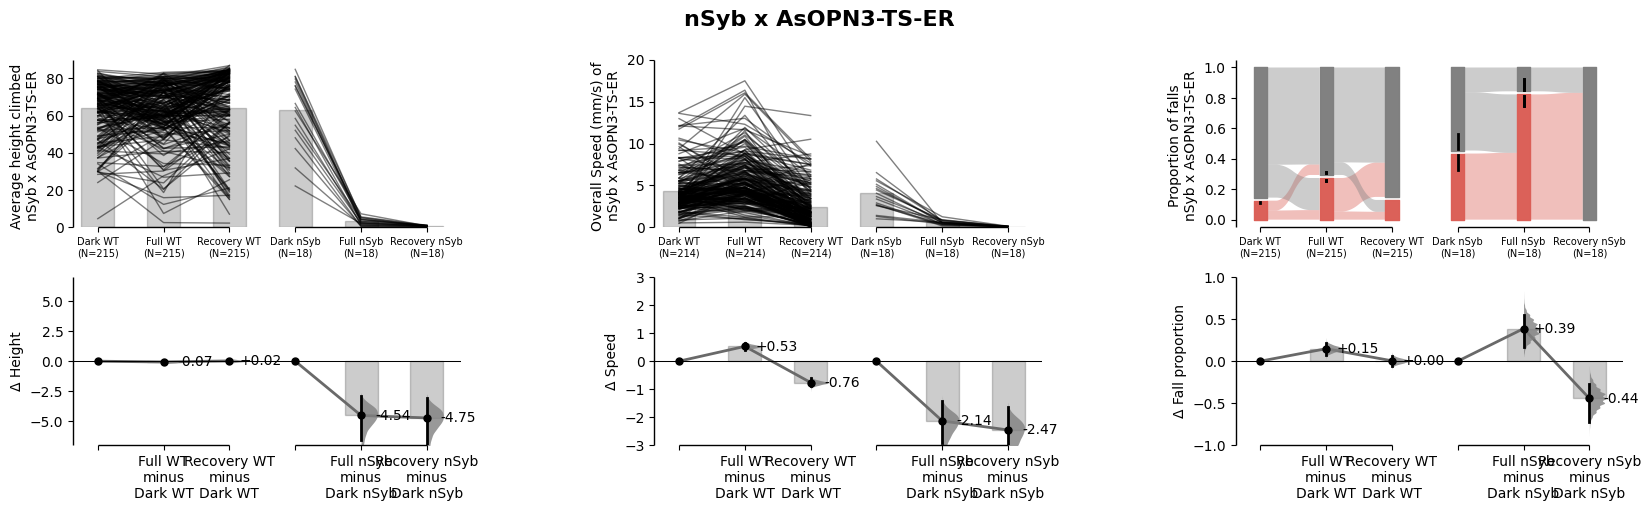

In [63]:
import seaborn as sns
f, axx = plt.subplots(nrows=1, ncols=3,
                    figsize=(20
                             ,5),
                    gridspec_kw={'wspace': 0.5
                                } # ensure proper width-wise spacing.
                   )

if 'eOPN3' in responder:
   responderrename = responder.replace("eOPN3", "AsOPN3").replace("(iii)M4", " ")
   #responderrename = responder.replace("ACR[ATR]", "ACR")
   transgenic = driver + " x " + responderrename

totalclimber.hedges_g.plot(raw_label="Average height climbed \n" + transgenic,
                                    contrast_label="Δ Height", raw_ylim = (0,90), contrast_ylim=(-7, 7),  fontsize_rawxlabel=7, fontsize_rawylabel=10, fontsize_contrastxlabel=10, contrast_marker_size=5,
                                    fontsize_contrastylabel=10, fontsize_delta2label=10,
                                    ax=axx.flat[0]);
# axx[0].legend_.remove()

overallspeed.hedges_g.plot(raw_label="Overall Speed (mm/s) of \n" + transgenic ,contrast_label="Δ Speed",
                                       contrast_marker_size=5, raw_ylim=(0,20), contrast_ylim=(-3, 3),  fontsize_rawxlabel=7, fontsize_rawylabel=10, fontsize_contrastxlabel=10, 
                                    fontsize_contrastylabel=10, fontsize_delta2label=10,
                                    ax=axx.flat[1]);       #contrast_label="Δ Speed",
# axx[1].legend_.remove()

paired_prop2.mean_diff.plot(raw_label = "Proportion of falls \n" + transgenic,contrast_ylim=(-1, 1), fontsize_rawxlabel=7, fontsize_rawylabel=10, fontsize_contrastxlabel=10, contrast_marker_size=5,
                                    fontsize_contrastylabel=10, fontsize_delta2label=10, contrast_label="Δ Fall proportion", ax=axx.flat[2]);

f.suptitle(transgenic, fontsize = 16, fontweight='bold')

##need to run this
# deltaplots.delta_g.plot(raw_label="Falling occurence of \n" + transgenic,
#                                      contrast_label="Δ Falls", raw_marker_size=2, es_marker_size=10, swarm_ylim=(0,5), contrast_ylim=(-2, 2), ax=axx.flat[2]);

#f.savefig(savefiglocation + "threedabestplots_" + date + "_" + transgenic + ".svg")